In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("08-seismic_activity_svm.csv")

In [3]:
df.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   underground_wave_energy   400 non-null    float64
 1   vibration_axis_variation  400 non-null    float64
 2   seismic_event_detected    400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


In [5]:
df.describe()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
count,400.000000,4.000000e+02,400.000000
mean,0.000000,8.881784e-18,0.500000
std,7.719350,1.751650e+00,0.500626
min,-9.999954,-3.000000e+00,0.000000
25%,-6.134779,-1.500000e+00,0.000000
50%,0.000000,0.000000e+00,0.500000
75%,6.134779,1.500000e+00,1.000000
max,9.999954,3.000000e+00,1.000000


In [6]:
df['seismic_event_detected'].unique()

array([0, 1])

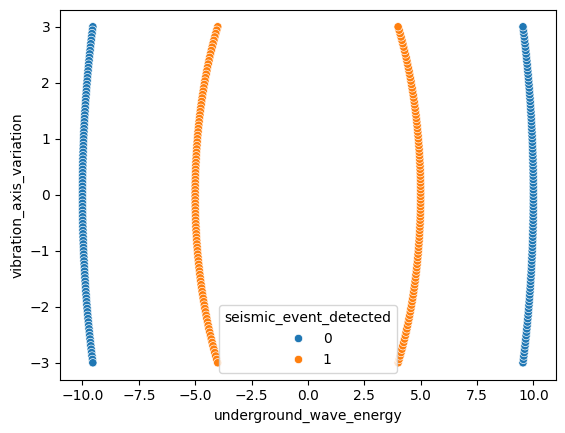

In [7]:
sns.scatterplot(x = df["underground_wave_energy"], y = df['vibration_axis_variation'], hue=df["seismic_event_detected"])
plt.show()

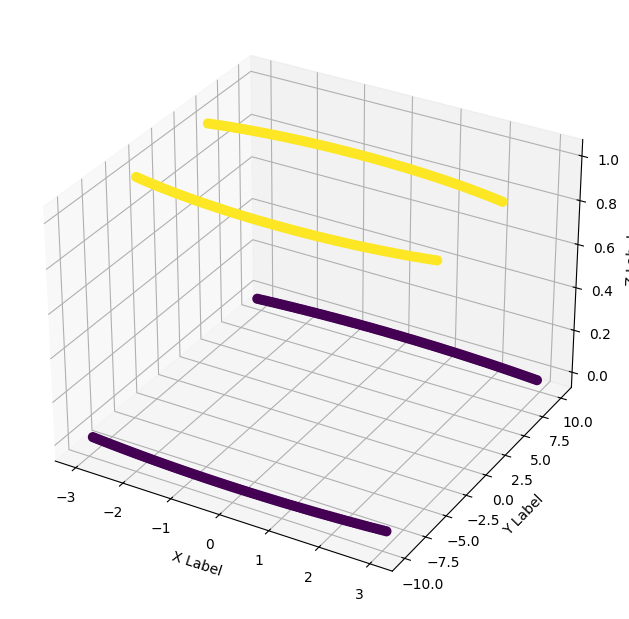

In [8]:
from mpl_toolkits.mplot3d import Axes3D

x = df["vibration_axis_variation"]
y = df["underground_wave_energy"]
z = df["seismic_event_detected"]

fig = plt.figure(figsize=(6,6))
ax = Axes3D(fig, auto_add_to_figure=False)
fig.add_axes(ax)

sc = ax.scatter(x, y, z,
                s=40,
                c=z,
                cmap='viridis',
                marker='o',
                alpha=1)
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

plt.show()

In [9]:
X = df[['underground_wave_energy', 'vibration_axis_variation']].values
y = df['seismic_event_detected'].values

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [13]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([320, 2]) torch.Size([320, 1])
torch.Size([80, 2]) torch.Size([80, 1])


In [14]:
from torch import nn

In [15]:
class ClassificationNonLinearModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(in_features=2, out_features=6)
        self.layer2 = nn.Linear(in_features=6, out_features=6)
        self.layer3 = nn.Linear(in_features=6, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, x):
      # ReLU function between layers
       return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))

In [16]:
model_0 = ClassificationNonLinearModel()

In [17]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001) # try with SGD and Adam, you will see the difference
def calculate_accuracy(y_test, y_pred):
    correct = torch.eq(y_test, y_pred).sum().item() # torch.eq() calculates when two tensors are equal
    accuracy = (correct / len(y_pred)) * 100
    return accuracy

In [18]:
torch.manual_seed(42)
epochs = 401

for epoch in range(epochs):
    # 1. Forward pass
    y_logits = model_0(X_train)
    y_pred = torch.round(torch.sigmoid(y_logits))

    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_train)
    acc = calculate_accuracy(y_test=y_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_0.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_logits = model_0(X_test)
      test_pred = torch.round(torch.sigmoid(test_logits)) # logits -> prediction probabilities -> prediction labels
      # 2. Calculate loss and accuracy
      test_loss = loss_fn(test_logits, y_test)
      test_acc = calculate_accuracy(y_test=y_test,
                             y_pred=test_pred)


    if epoch % 20 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.75000, Accuracy: 67.81% | Test Loss: 0.72852, Test Accuracy: 71.25%
Epoch: 20 | Loss: 0.71554, Accuracy: 60.94% | Test Loss: 0.68721, Test Accuracy: 63.75%
Epoch: 40 | Loss: 0.68991, Accuracy: 55.62% | Test Loss: 0.65548, Test Accuracy: 58.75%
Epoch: 60 | Loss: 0.67149, Accuracy: 52.81% | Test Loss: 0.63409, Test Accuracy: 57.50%
Epoch: 80 | Loss: 0.65610, Accuracy: 51.56% | Test Loss: 0.61897, Test Accuracy: 57.50%
Epoch: 100 | Loss: 0.63476, Accuracy: 52.50% | Test Loss: 0.59992, Test Accuracy: 56.25%
Epoch: 120 | Loss: 0.61677, Accuracy: 57.50% | Test Loss: 0.58462, Test Accuracy: 60.00%
Epoch: 140 | Loss: 0.59892, Accuracy: 57.50% | Test Loss: 0.56577, Test Accuracy: 61.25%
Epoch: 160 | Loss: 0.58024, Accuracy: 61.56% | Test Loss: 0.55014, Test Accuracy: 66.25%
Epoch: 180 | Loss: 0.56013, Accuracy: 64.38% | Test Loss: 0.53222, Test Accuracy: 70.00%
Epoch: 200 | Loss: 0.53829, Accuracy: 68.12% | Test Loss: 0.51252, Test Accuracy: 71.25%
Epoch: 220 | Loss: 0.51453,

In [19]:
def plot_nonlinear_decision_boundary(model, X, y):

    # Grid alanını tanımla (tüm veri aralığını kapsasın)
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Grid'i modele sokmak için tensor'a çevir
    grid_points = torch.tensor(
        np.c_[xx.ravel(), yy.ravel()],
        dtype=torch.float32
    )

    # Tahmin al
    model.eval()
    with torch.inference_mode():
        logits = model(grid_points)
        preds = torch.sigmoid(logits).numpy().reshape(xx.shape)  # probability map

    # Decision boundary çizimi (0.5 threshold)
    plt.contourf(xx, yy, preds, cmap=plt.cm.RdYlBu, alpha=0.7)

    # Gerçek noktalar
    plt.scatter(X[:,0], X[:,1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=30, edgecolor="k")
    plt.xlabel("underground_wave_energy")
    plt.ylabel("vibration_axis_variation")
    plt.title("Non-linear Decision Boundary")

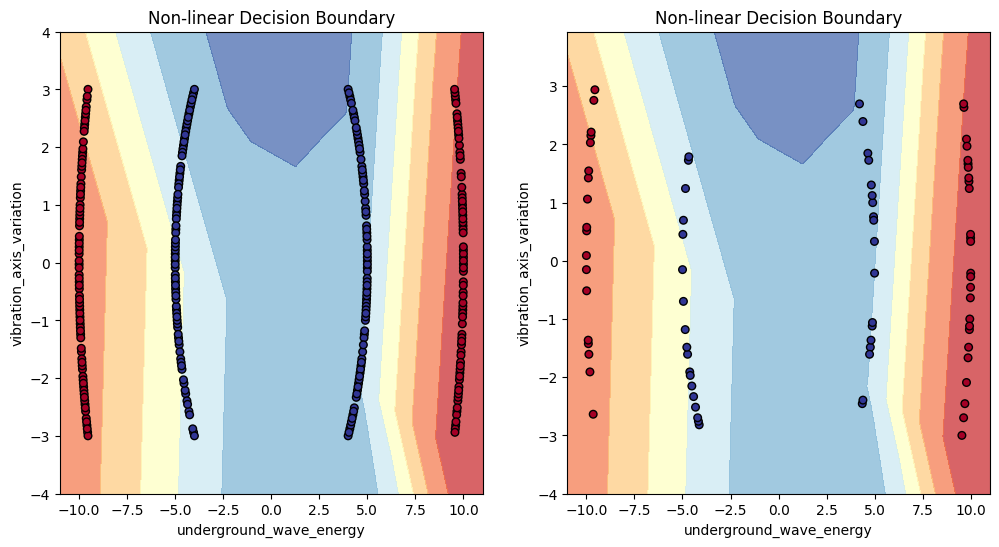

In [20]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_nonlinear_decision_boundary(model_0, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_nonlinear_decision_boundary(model_0, X_test, y_test)

plt.show()